In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # ignore warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Read csv file
df = pd.read_csv('cardio_data_processed.csv')

In [3]:
# Get summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   68205 non-null  int64  
 1   age                  68205 non-null  int64  
 2   gender               68205 non-null  int64  
 3   height               68205 non-null  int64  
 4   weight               68205 non-null  float64
 5   ap_hi                68205 non-null  int64  
 6   ap_lo                68205 non-null  int64  
 7   cholesterol          68205 non-null  int64  
 8   gluc                 68205 non-null  int64  
 9   smoke                68205 non-null  int64  
 10  alco                 68205 non-null  int64  
 11  active               68205 non-null  int64  
 12  cardio               68205 non-null  int64  
 13  age_years            68205 non-null  int64  
 14  bmi                  68205 non-null  float64
 15  bp_category          68205 non-null 

In [4]:
# Get preview of values in dataset
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,bp_category,bp_category_encoded
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,Hypertension Stage 1,Hypertension Stage 1
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,Hypertension Stage 2,Hypertension Stage 2
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,Hypertension Stage 1,Hypertension Stage 1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,Hypertension Stage 2,Hypertension Stage 2
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,Normal,Normal


In [5]:
# Drop irrelevant columns
df = df.drop(columns = ['id', 'age', 'height', 'weight', 'bp_category_encoded', 'ap_hi', 'ap_lo'])

In [6]:
# Rename age_years
df = df.rename(columns = {'age_years': 'age'})

In [7]:
# New dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68205 entries, 0 to 68204
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   gender       68205 non-null  int64  
 1   cholesterol  68205 non-null  int64  
 2   gluc         68205 non-null  int64  
 3   smoke        68205 non-null  int64  
 4   alco         68205 non-null  int64  
 5   active       68205 non-null  int64  
 6   cardio       68205 non-null  int64  
 7   age          68205 non-null  int64  
 8   bmi          68205 non-null  float64
 9   bp_category  68205 non-null  object 
dtypes: float64(1), int64(8), object(1)
memory usage: 5.2+ MB


In [8]:
# Check for missing values
df.isnull().sum()

gender         0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age            0
bmi            0
bp_category    0
dtype: int64

In [9]:
# Check for sum of duplicates
df.duplicated().sum()

5652

In [10]:
# Inspect sample of duplicates
dupes = df[df.duplicated(keep=False)]
dupes.sort_values(list(df.columns)).head(20)  # look at first 20

,gender,cholesterol,gluc,smoke,alco,active,cardio,age,bmi,bp_category
4650,1,1,1,0,0,0,0,39,19.814053,Normal
28405,1,1,1,0,0,0,0,39,19.814053,Normal
29071,1,1,1,0,0,0,0,39,22.773186,Hypertension Stage 1
68054,1,1,1,0,0,0,0,39,22.773186,Hypertension Stage 1
5289,1,1,1,0,0,0,0,39,23.875115,Hypertension Stage 1
24557,1,1,1,0,0,0,0,39,23.875115,Hypertension Stage 1
50952,1,1,1,0,0,0,0,39,25.529645,Normal
54371,1,1,1,0,0,0,0,39,25.529645,Normal
17401,1,1,1,0,0,0,0,39,27.343750,Hypertension Stage 1
21238,1,1,1,0,0,0,0,39,27.343750,Hypertension Stage 1


In [11]:
# Check dataframe shape before dropping duplicates
print("Before dropping:", df.shape)
# Drop duplicates
df = df.drop_duplicates()
# Check dataframe shape after dropping duplicates
print("After dropping:", df.shape)

Before dropping: (68205, 10)
After dropping: (62553, 10)


In [12]:
# Get unique value count for "gender"
df["gender"].value_counts() # 1 for female, 2 for male

gender
1    39957
2    22596
Name: count, dtype: int64

In [13]:
# Get unique value count for "cholesterol"
df["cholesterol"].value_counts() # 1 for normal, 2 for above normal, 3 for well above normal

cholesterol
1    45766
2     9112
3     7675
Name: count, dtype: int64

In [14]:
# Get unique value count for "gluc"
df["gluc"].value_counts() # 1 for normal, 2 for above normal, 3 for well above normal

gluc
1    52470
3     5106
2     4977
Name: count, dtype: int64

In [15]:
# Get unique value count for "smoke"
df["smoke"].value_counts() # 0 for non-smoker, 1 for smoker

smoke
0    56611
1     5942
Name: count, dtype: int64

In [16]:
# Get unique value count for "alco"
df["alco"].value_counts() # 0 for doesn't consume alcohol, 1 for consumes alcohol

alco
0    58938
1     3615
Name: count, dtype: int64

In [17]:
# Get unique value count for "active"
df["active"].value_counts() # 0 for not physically active, 1 for physically active

active
1    49633
0    12920
Name: count, dtype: int64

In [18]:
# Get unique value count for "bp_category"
df["bp_category"].value_counts()

bp_category
Hypertension Stage 1    35099
Hypertension Stage 2    15441
Normal                   8968
Elevated                 3045
Name: count, dtype: int64

In [19]:
# Convert values in gender to 0/1 (male = 1, female = 0); rename gender_name
df['gender_male'] = df['gender'].map({1: 0, 2: 1})
df.drop(columns=['gender'], inplace=True)

# Get dummy variables for 'cholesterol' and 'gluc,' drop first category to prevent multicollinearity
df = pd.get_dummies(df, columns=['cholesterol', 'gluc'], drop_first=True)

# Rename columns for clarity
df.rename(columns={
    'cholesterol_2': 'cholesterol_above_normal',
    'cholesterol_3': 'cholesterol_well_above_normal',
    'gluc_2': 'glucose_above_normal',
    'gluc_3': 'glucose_well_above_normal'
}, inplace=True)

# Convert bp_category into category data type
df['bp_category'] = df['bp_category'].astype('category')
# Define order for categories
order = ["Normal", "Elevated", "Hypertension Stage 1", "Hypertension Stage 2"]
df['bp_category'] = pd.Categorical(df['bp_category'], categories=order, ordered=True)

# Get dummy variables for bp_category
bp_dummies = pd.get_dummies(df['bp_category'], prefix='bp', dtype=int, drop_first=True)
# Set column names to lowercase, replace blank spaces with underscores
bp_dummies.columns = (bp_dummies.columns
                      .str.lower()
                      .str.replace(' ', '_'))

# Add bp_dummies to df
df = pd.concat([df, bp_dummies], axis=1)

# Drop bp_category
df.drop(columns=['bp_category'], inplace=True)

In [20]:
# Convert dummy variables into binary value (0/1)
true_false = {True: 1, False: 0}
df["cholesterol_above_normal"] = df["cholesterol_above_normal"].replace(true_false).infer_objects(copy=False)
df["cholesterol_well_above_normal"] = df["cholesterol_well_above_normal"].replace(true_false).infer_objects(copy=False)
df["glucose_above_normal"] = df["glucose_above_normal"].replace(true_false).infer_objects(copy=False)
df["glucose_well_above_normal"] = df["glucose_well_above_normal"].replace(true_false).infer_objects(copy=False)

In [21]:
# Recheck dataframe summary
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62553 entries, 0 to 68204
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   smoke                          62553 non-null  int64  
 1   alco                           62553 non-null  int64  
 2   active                         62553 non-null  int64  
 3   cardio                         62553 non-null  int64  
 4   age                            62553 non-null  int64  
 5   bmi                            62553 non-null  float64
 6   gender_male                    62553 non-null  int64  
 7   cholesterol_above_normal       62553 non-null  int64  
 8   cholesterol_well_above_normal  62553 non-null  int64  
 9   glucose_above_normal           62553 non-null  int64  
 10  glucose_well_above_normal      62553 non-null  int64  
 11  bp_elevated                    62553 non-null  int64  
 12  bp_hypertension_stage_1        62553 non-null  int6

In [22]:
# Get preview of data
df.head()

,smoke,alco,active,cardio,age,bmi,gender_male,cholesterol_above_normal,cholesterol_well_above_normal,glucose_above_normal,glucose_well_above_normal,bp_elevated,bp_hypertension_stage_1,bp_hypertension_stage_2
0,0,0,1,0,50,21.967120,1,0,0,0,0,0,1,0
1,0,0,1,1,55,34.927679,0,0,1,0,0,0,0,1
2,0,0,0,1,51,23.507805,0,0,1,0,0,0,1,0
3,0,0,1,1,48,28.710479,1,0,0,0,0,0,0,1
4,0,0,0,0,47,23.011177,0,0,0,0,0,0,0,0


In [23]:
# Get summary statistics (pre-outlier handling)
df[['age', 'bmi']].describe()

,age,bmi
count,62553.000000,62553.000000
mean,52.826547,27.698470
std,6.826683,6.195161
min,29.000000,3.471784
25%,48.000000,23.875433
50%,53.000000,26.575891
75%,58.000000,30.477219
max,64.000000,298.666667


In [24]:
# Handle outliers in bmi with winsorization
lower, upper = df['bmi'].quantile([0.01, 0.99])
df['bmi'] = df['bmi'].clip(lower, upper)

In [25]:
# Get summary statistics (post-outlier handling)
df['bmi'].describe()

count    62553.000000
mean        27.607666
std          5.164575
min         18.507766
25%         23.875433
50%         26.575891
75%         30.477219
max         44.581619
Name: bmi, dtype: float64

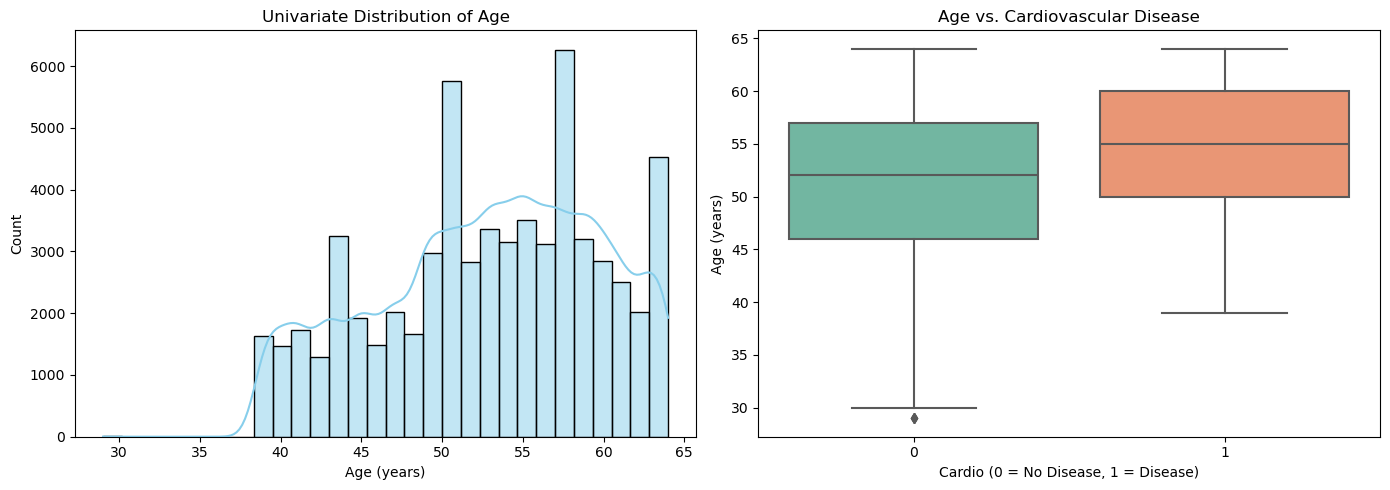

In [26]:
# Visualizations for age

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Univariate (age) ---
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Univariate Distribution of Age")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Count")

# --- Right: Bivariate (Age vs cardio) ---
sns.boxplot(x='cardio', y='age', data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Age vs. Cardiovascular Disease")
axes[1].set_xlabel("Cardio (0 = No Disease, 1 = Disease)")
axes[1].set_ylabel("Age (years)")

plt.tight_layout()
plt.show()

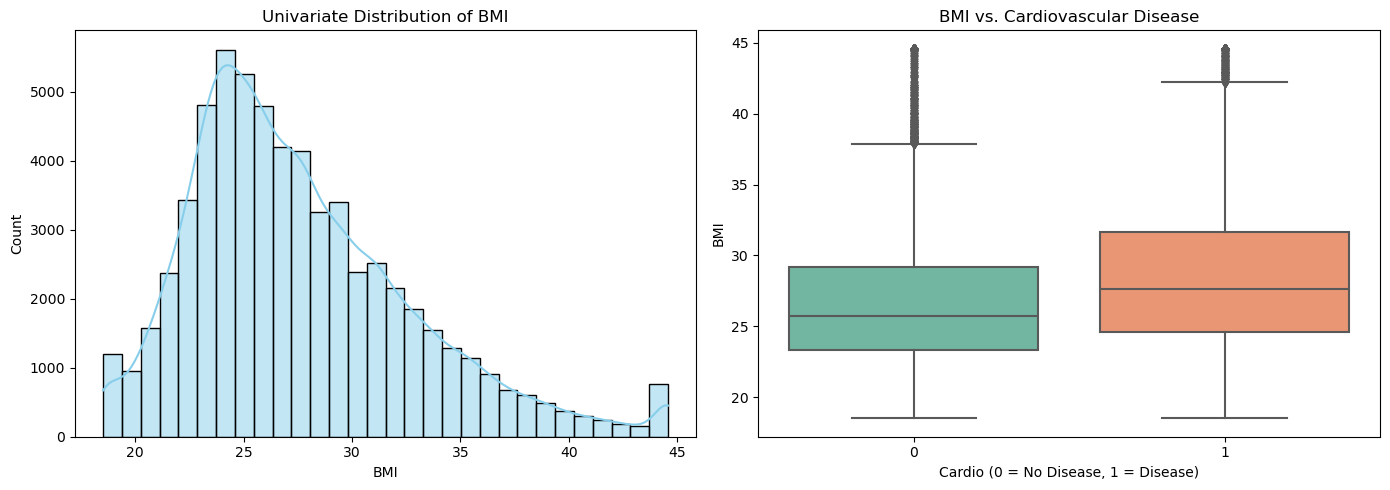

In [27]:
# Visualizations for bmi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Univariate BMI ---
sns.histplot(df['bmi'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Univariate Distribution of BMI")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Count")

# --- Right: Bivariate (BMI vs cardio) ---
sns.boxplot(x='cardio', y='bmi', data=df, ax=axes[1], palette="Set2")
axes[1].set_title("BMI vs. Cardiovascular Disease")
axes[1].set_xlabel("Cardio (0 = No Disease, 1 = Disease)")
axes[1].set_ylabel("BMI")

plt.tight_layout()
plt.show()

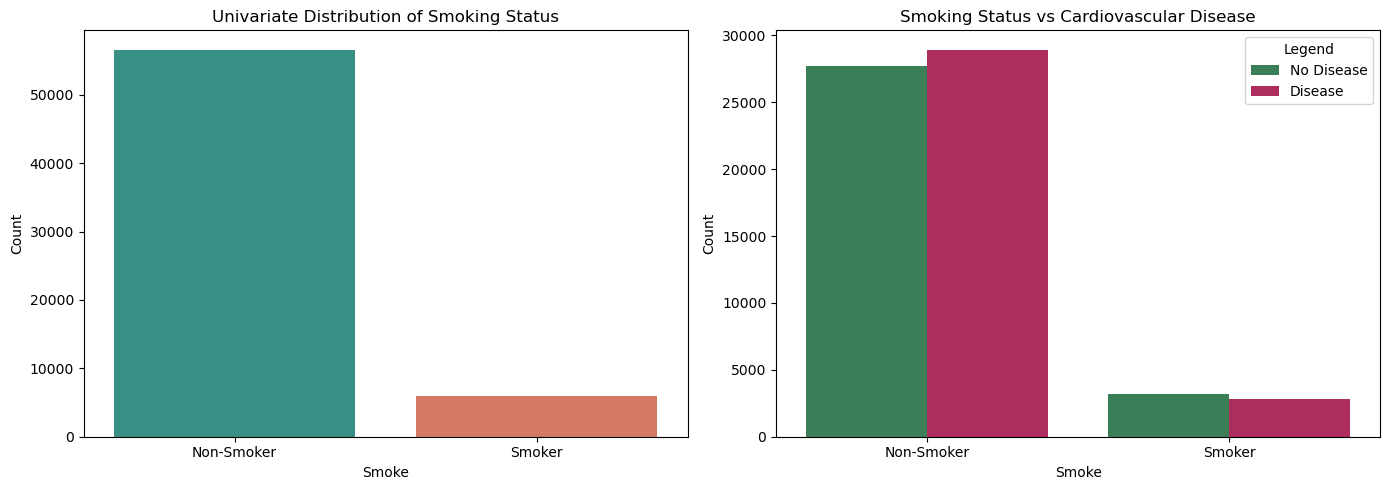

In [28]:
# Visualizations for smoke

# Make readable labels
df['smoke_label']  = df['smoke'].map({0: 'Non-Smoker', 1: 'Smoker'})
df['cardio_label'] = df['cardio'].map({0: 'No Disease', 1: 'Disease'})

# Color palette
smoke_palette  = ['#2A9D8F', '#E76F51']  # Non-Smoker, Smoker
cardio_palette = {'No Disease':'#2E8B57', 'Disease':'#C2185B'} 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Univariate Smoker ---
sns.countplot(x='smoke_label', data=df, ax=axes[0], palette=smoke_palette)
axes[0].set_title('Univariate Distribution of Smoking Status')
axes[0].set_xlabel('Smoke')
axes[0].set_ylabel('Count')

# --- Right: Bivariate (Smoker vs cardio) ---
sns.countplot(x='smoke_label', hue='cardio_label', data=df,
              palette=cardio_palette, hue_order=['No Disease','Disease'], ax=axes[1])
axes[1].set_title('Smoking Status vs Cardiovascular Disease')
axes[1].set_xlabel('Smoke')
axes[1].set_ylabel('Count')
axes[1].legend(title='Legend')

plt.tight_layout()
plt.show()

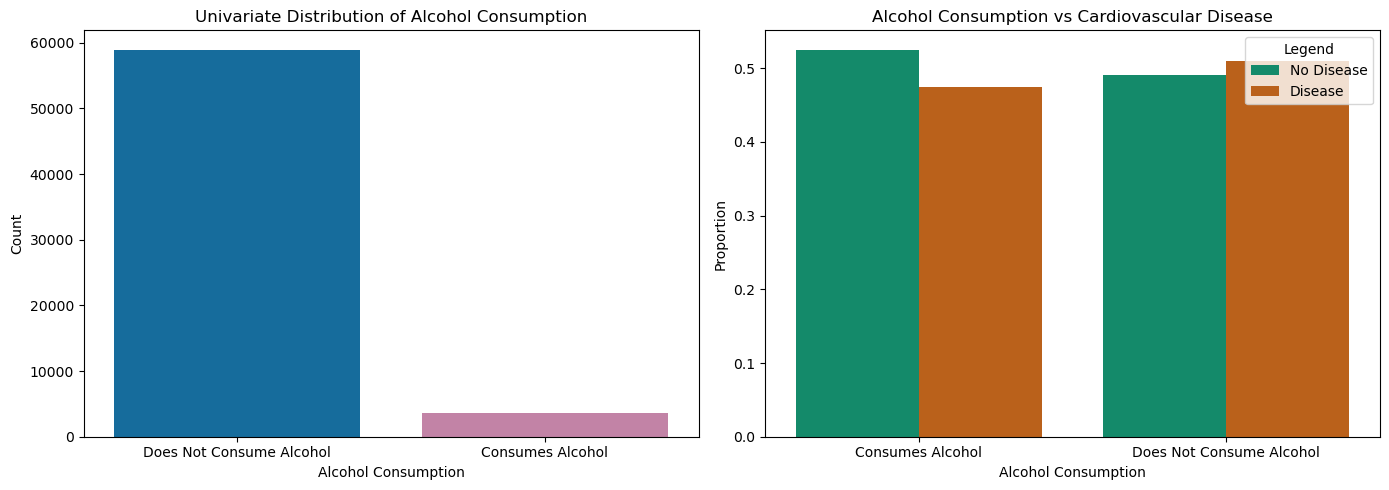

In [29]:
# Visualization for alco

# Make readable labels (avoid overwriting if they already exist)
tmp = df.assign(
    alco_label   = df['alco'].map({0: 'Does Not Consume Alcohol', 1: 'Consumes Alcohol'}),
    cardio_label = df['cardio'].map({0: 'No Disease', 1: 'Disease'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Palettes
alco_palette = ['#0072B2', '#CC79A7'] 
cardio_palette = {'No Disease':'#009E73', 'Disease':'#D55E00'}

# --- Left: Univariate Alcohol ---
sns.countplot(x='alco_label', data=tmp, ax=axes[0], palette=alco_palette)
axes[0].set_title("Univariate Distribution of Alcohol Consumption")
axes[0].set_xlabel("Alcohol Consumption")
axes[0].set_ylabel("Count")

# --- Build proportion table for bivariate ---
prop = (pd.crosstab(tmp['alco_label'], tmp['cardio_label'], normalize='index')
          .stack().rename('proportion').reset_index())

# --- Right: Bivariate (Alcohol vs Cardio) ---
sns.barplot(x='alco_label', y='proportion', hue='cardio_label',
            data=prop, ax=axes[1], palette=cardio_palette,
            hue_order=['No Disease','Disease'])
axes[1].set_title("Alcohol Consumption vs Cardiovascular Disease")
axes[1].set_xlabel("Alcohol Consumption")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="Legend")

plt.tight_layout()
plt.show()

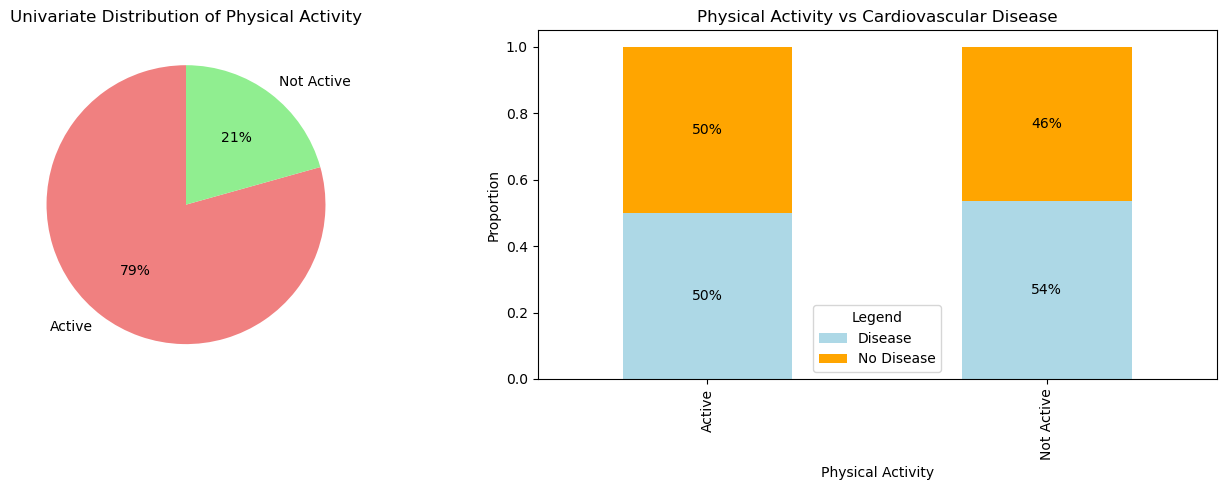

In [30]:
# Visualization for active

# Map labels for readability
tmp = df.assign(
    active_label = df['active'].map({0:'Not Active', 1:'Active'}),
    cardio_label = df['cardio'].map({0:'No Disease', 1:'Disease'})
)

# Proportion table for bivariate
prop = pd.crosstab(tmp['active_label'], tmp['cardio_label'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Univariate Active ---
active_counts = tmp['active_label'].value_counts()
axes[0].pie(active_counts, labels=active_counts.index, autopct='%1.0f%%',
            colors=['lightcoral','lightgreen'], startangle=90)
axes[0].set_title("Univariate Distribution of Physical Activity")

# --- Right: Bivariate (Active vs Cardio) ---
prop.plot(kind='bar', stacked=True, ax=axes[1], color=['lightblue','orange'])
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('Physical Activity')
axes[1].set_title('Physical Activity vs Cardiovascular Disease')
axes[1].legend(title='Legend')

# Add percentage labels inside bars
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    if height > 0.03:  # only annotate if large enough
        x, y = p.get_x() + width/2, p.get_y() + height/2
        axes[1].text(x, y, f"{height*100:.0f}%", ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

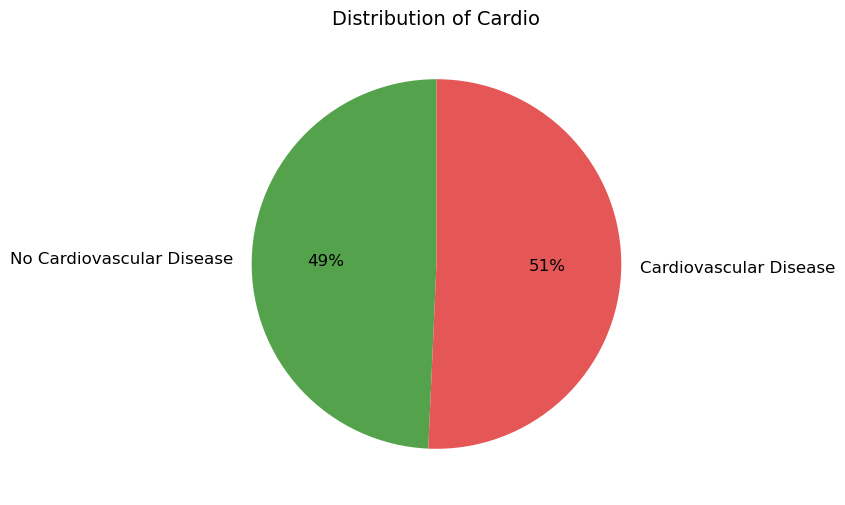

In [31]:
# Distribution of cardio (target variable)

# Count values and map labels
cardio_counts = df['cardio'].value_counts().sort_index()
labels = ['No Cardiovascular Disease', 'Cardiovascular Disease']
colors = ['#54A24B', '#E45756']  # green for healthy, red for disease

plt.figure(figsize=(6,6))
plt.pie(cardio_counts, labels=labels, autopct='%1.0f%%', startangle=90,
        colors=colors, textprops={'fontsize': 12})
plt.title("Distribution of Cardio", fontsize=14)
plt.show()

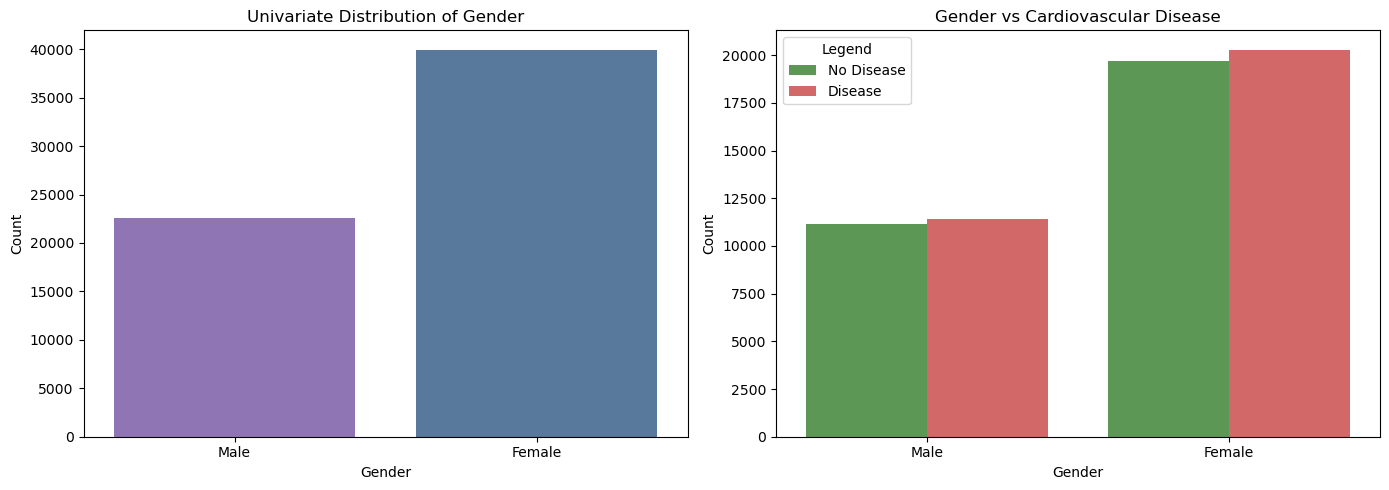

In [32]:
# Visualization for gender

# Make labels
tmp = df.assign(
    gender_label = df['gender_male'].map({0: 'Female', 1: 'Male'}),
    cardio_label = df['cardio'].map({0: 'No Disease', 1: 'Disease'})
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Univariate Gender ---
sns.countplot(x='gender_label', data=tmp, ax=axes[0], palette=['#8E6BBE','#4C78A8'])
axes[0].set_title("Univariate Distribution of Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Count")

# --- Right: Bivariate (Gender vs Cardio) ---
sns.countplot(x='gender_label', hue='cardio_label', data=tmp,
              ax=axes[1], palette={'No Disease':'#54A24B', 'Disease':'#E45756'})
axes[1].set_title("Gender vs Cardiovascular Disease")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Count")
axes[1].legend(title="Legend")

plt.tight_layout()
plt.show()

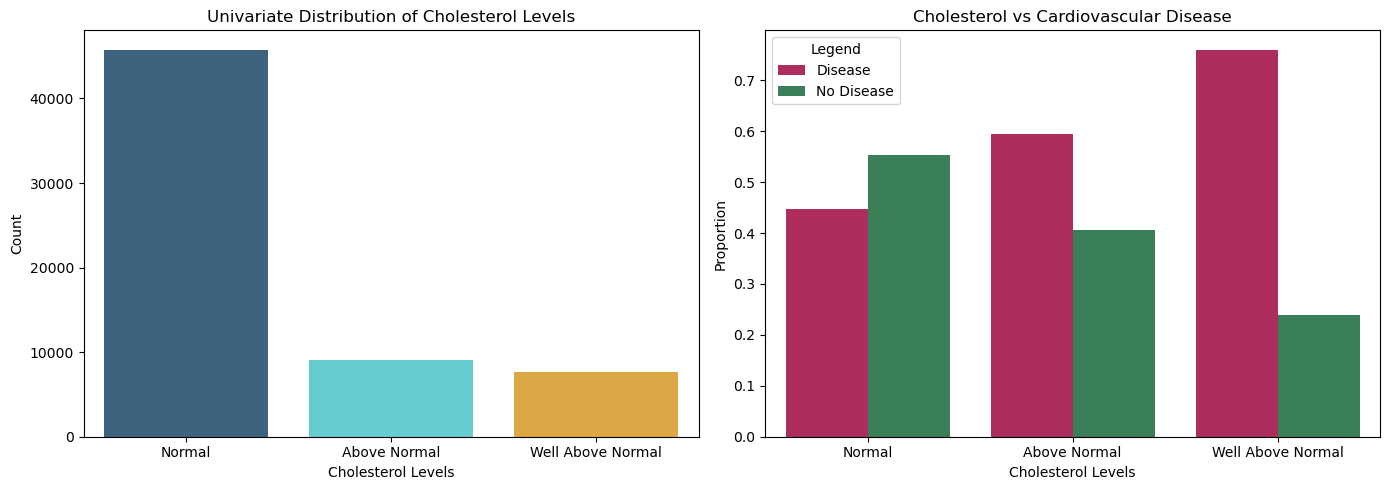

In [33]:
# Visualization for cholesterol

# Recombine cholesterol dummy variables into one categorical variable
def chol_category(row):
    if row['cholesterol_above_normal'] == 1:
        return 'Above Normal'
    elif row['cholesterol_well_above_normal'] == 1:
        return 'Well Above Normal'
    else:
        return 'Normal'

tmp = df.copy()
tmp['cholesterol_label'] = tmp.apply(chol_category, axis=1)
tmp['cardio_label'] = tmp['cardio'].map({0:'No Disease', 1:'Disease'})

# Proportion table for bivariate
prop = (pd.crosstab(tmp['cholesterol_label'], tmp['cardio_label'], normalize='index')
          .stack().rename('proportion').reset_index())

# New palettes
chol_palette = ['#33658A', '#55DDE0', '#F6AE2D']  # Normal, Above, Well Above
cardio_palette = {'No Disease':'#2E8B57', 'Disease':'#C2185B'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Univariate Cholesterol ---
sns.countplot(x='cholesterol_label', data=tmp,
              order=['Normal','Above Normal','Well Above Normal'],
              palette=chol_palette, ax=axes[0])
axes[0].set_title("Univariate Distribution of Cholesterol Levels")
axes[0].set_xlabel("Cholesterol Levels")
axes[0].set_ylabel("Count")

# --- Right: Bivariate (Cholesterol vs Cardio) ---
sns.barplot(x='cholesterol_label', y='proportion', hue='cardio_label',
            data=prop, order=['Normal','Above Normal','Well Above Normal'],
            palette=cardio_palette, ax=axes[1])
axes[1].set_title("Cholesterol vs Cardiovascular Disease")
axes[1].set_xlabel("Cholesterol Levels")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="Legend")

plt.tight_layout()
plt.show()

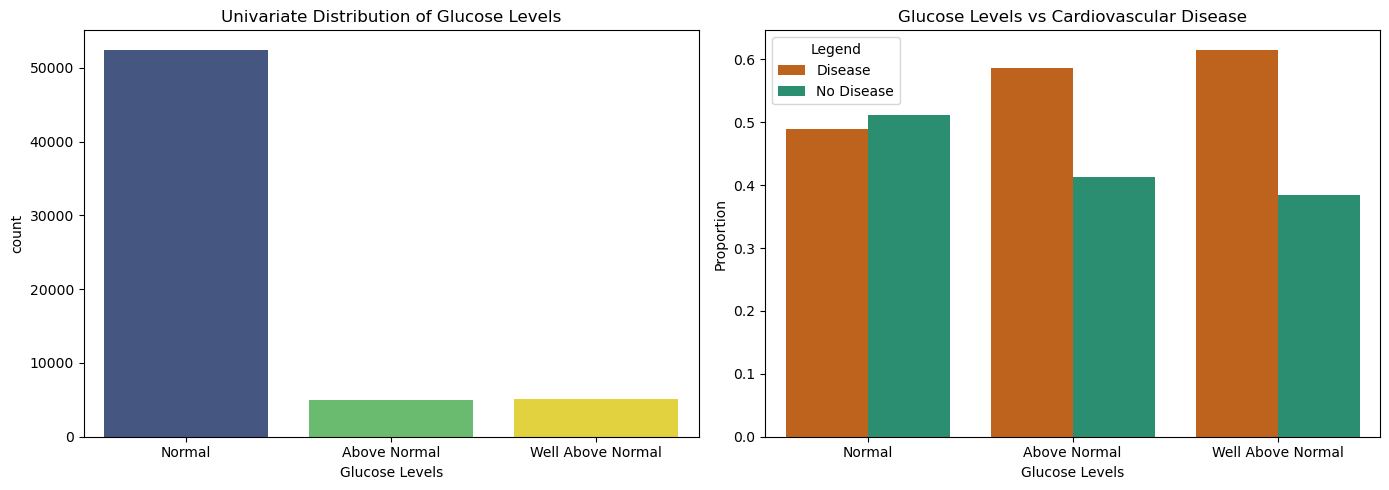

In [34]:
# Visualization for glucose

# Recombine glucose dummy variables into one categorical variable
def gluc_category(row):
    if row['glucose_above_normal'] == 1:
        return 'Above Normal'
    elif row['glucose_well_above_normal'] == 1:
        return 'Well Above Normal'
    else:
        return 'Normal'

tmp = df.copy()
tmp['glucose_label'] = tmp.apply(gluc_category, axis=1)
tmp['cardio_label'] = tmp['cardio'].map({0:'No Disease', 1:'Disease'})

# Make proportion table for bivariate
prop = (pd.crosstab(tmp['glucose_label'], tmp['cardio_label'], normalize='index')
          .stack().rename('proportion').reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# New palettes
gluc_palette   = ['#3B528B', '#5DC863', '#FDE725']
cardio_palette = {'No Disease':'#1B9E77', 'Disease':'#D95F02'}

# --- Left: Univariate Glucose ---
sns.countplot(x='glucose_label', data=tmp,
              order=['Normal','Above Normal','Well Above Normal'],
              palette=gluc_palette, ax=axes[0])
axes[0].set_title("Univariate Distribution of Glucose Levels")
axes[0].set_xlabel("Glucose Levels")


# --- Right: Bivariate (Glucose vs Cardio) ---
sns.barplot(x='glucose_label', y='proportion', hue='cardio_label',
            data=prop, order=['Normal','Above Normal','Well Above Normal'],
            palette=cardio_palette, ax=axes[1])
axes[1].set_title("Glucose Levels vs Cardiovascular Disease")
axes[1].set_xlabel("Glucose Levels")
axes[1].set_ylabel("Proportion")
axes[1].legend(title='Legend')

plt.tight_layout()
plt.show()

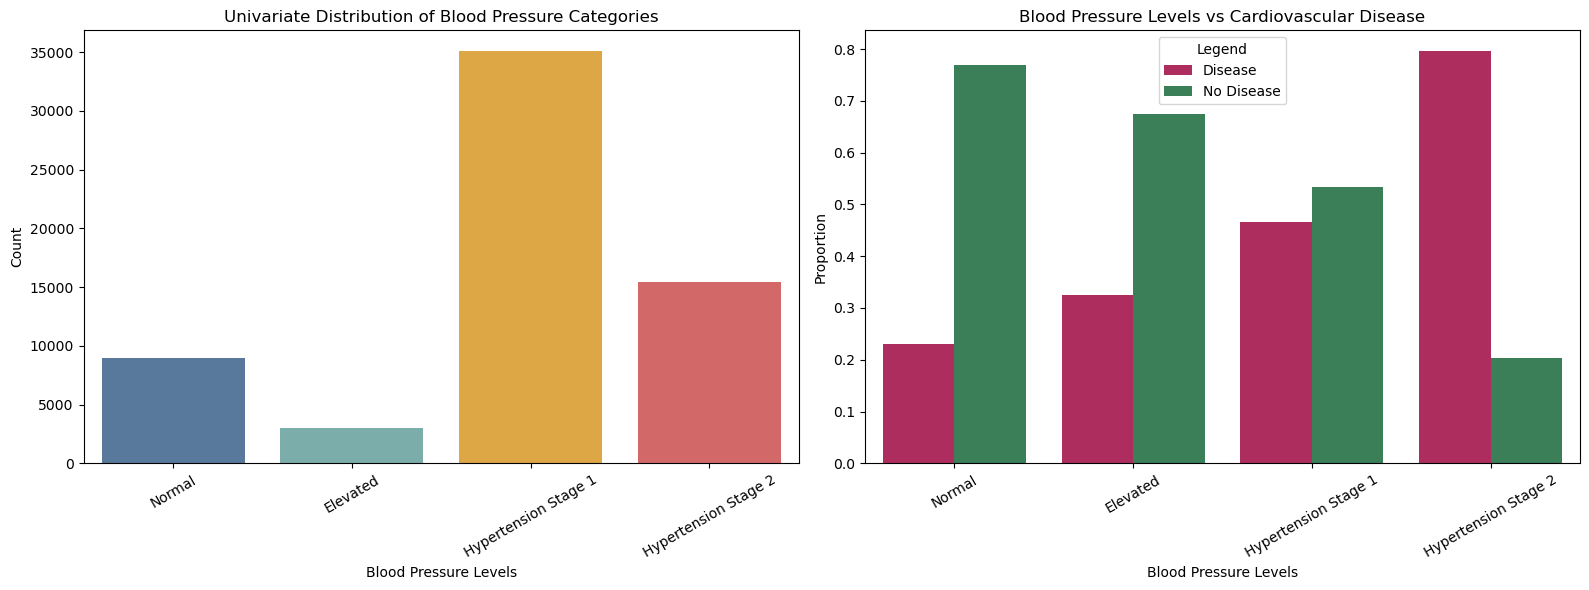

In [35]:
# Visualization for bp_category

# Recombine BP dummies into one categorical variable
def bp_category(row):
    if row['bp_elevated'] == 1:
        return 'Elevated'
    elif row['bp_hypertension_stage_1'] == 1:
        return 'Hypertension Stage 1'
    elif row['bp_hypertension_stage_2'] == 1:
        return 'Hypertension Stage 2'
    else:
        return 'Normal'

tmp = df.copy()
tmp['bp_label'] = tmp.apply(bp_category, axis=1)
tmp['cardio_label'] = tmp['cardio'].map({0:'No Disease', 1:'Disease'})

# Proportion table for bivariate
prop = (pd.crosstab(tmp['bp_label'], tmp['cardio_label'], normalize='index')
          .stack().rename('proportion').reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# New palette
bp_palette = ['#4C78A8', '#72B7B2', '#F6AE2D', '#E45756', '#B279A2']
cardio_palette = {'No Disease':'#2E8B57', 'Disease':'#C2185B'}

# --- Left: Univariate Blood Pressure ---
sns.countplot(x='bp_label', data=tmp,
              order=['Normal','Elevated','Hypertension Stage 1','Hypertension Stage 2'],
              palette=bp_palette, ax=axes[0])
axes[0].set_title("Univariate Distribution of Blood Pressure Categories")
axes[0].set_xlabel("Blood Pressure Levels")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)

# --- Right: Bivariate (Blood Pressure vs Cardiovascular Disease)  ---
sns.barplot(x='bp_label', y='proportion', hue='cardio_label',
            data=prop,
            order=['Normal','Elevated','Hypertension Stage 1','Hypertension Stage 2'],
            palette=cardio_palette, ax=axes[1])
axes[1].set_title("Blood Pressure Levels vs Cardiovascular Disease")
axes[1].set_xlabel("Blood Pressure Levels")
axes[1].set_ylabel("Proportion")
axes[1].legend(title="Legend")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [36]:
# Save cleaned dataset
df.to_csv('cardio_logistic.csv')

In [37]:
from sklearn.model_selection import train_test_split

X = df[['age', 'bmi', 'smoke', 'alco', 'active', 'gender_male', 'cholesterol_above_normal', 
        'cholesterol_well_above_normal','glucose_above_normal', 'glucose_well_above_normal','bp_elevated', 
        'bp_hypertension_stage_1','bp_hypertension_stage_2']]
y = df['cardio']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [38]:
# Create initial logistic regression model

X = df[['age', 'bmi', 'smoke', 'alco', 'active', 'gender_male', 'cholesterol_above_normal', 
        'cholesterol_well_above_normal','glucose_above_normal', 'glucose_well_above_normal','bp_elevated', 
        'bp_hypertension_stage_1','bp_hypertension_stage_2']]
y = df['cardio']

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Calculate VIFs for each independent variable
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# Display VIF 
print(vif_data)

X = sm.add_constant(X)  # Add intercept
initial_model = sm.Logit(y,X).fit()
print(initial_model.summary())

                         Variable        VIF
0                             age  27.207203
1                             bmi  24.135531
2                           smoke   1.374652
3                            alco   1.203984
4                          active   4.625421
5                     gender_male   1.799614
6        cholesterol_above_normal   1.312184
7   cholesterol_well_above_normal   1.544910
8            glucose_above_normal   1.188494
9       glucose_well_above_normal   1.420007
10                    bp_elevated   1.339654
11        bp_hypertension_stage_1   5.121771
12        bp_hypertension_stage_2   2.988324
Optimization terminated successfully.
         Current function value: 0.586037
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 cardio   No. Observations:                62553
Model:                          Logit   Df Residuals:                    62539
Method:                        

In [39]:
# Remove "age" with VIF of 27.207203
X = df[['bmi', 'smoke', 'alco', 'active', 'gender_male', 'cholesterol_above_normal', 
        'cholesterol_well_above_normal','glucose_above_normal', 'glucose_well_above_normal','bp_elevated', 
        'bp_hypertension_stage_1','bp_hypertension_stage_2']]
y = df['cardio']

# Calculate VIFs for each independent variable
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# Display VIF 
print(vif_data)

X = sm.add_constant(X)  # Add intercept
model = sm.Logit(y,X).fit()
print(model.summary())

                         Variable       VIF
0                             bmi  9.603249
1                           smoke  1.374376
2                            alco  1.203098
3                          active  4.346221
4                     gender_male  1.764513
5        cholesterol_above_normal  1.310768
6   cholesterol_well_above_normal  1.543880
7            glucose_above_normal  1.188121
8       glucose_well_above_normal  1.419244
9                     bp_elevated  1.294681
10        bp_hypertension_stage_1  4.709073
11        bp_hypertension_stage_2  2.861677
Optimization terminated successfully.
         Current function value: 0.598934
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 cardio   No. Observations:                62553
Model:                          Logit   Df Residuals:                    62540
Method:                           MLE   Df Model:                           12
Date:     

In [40]:
# Remove "glucose_above_normal" with p-value of 0.227
X = df[['bmi', 'smoke', 'alco', 'active', 'gender_male', 'cholesterol_above_normal', 
        'cholesterol_well_above_normal', 'glucose_well_above_normal','bp_elevated', 
        'bp_hypertension_stage_1','bp_hypertension_stage_2']]
y = df['cardio']


# Calculate VIFs for each independent variable
vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# Display VIF 
print(vif_data)

X = sm.add_constant(X)  # Add intercept
final_model = sm.Logit(y,X).fit()
# Print final model
print(final_model.summary())

                         Variable       VIF
0                             bmi  9.533774
1                           smoke  1.374373
2                            alco  1.202891
3                          active  4.344685
4                     gender_male  1.764428
5        cholesterol_above_normal  1.223364
6   cholesterol_well_above_normal  1.539952
7       glucose_well_above_normal  1.406560
8                     bp_elevated  1.294251
9         bp_hypertension_stage_1  4.708710
10        bp_hypertension_stage_2  2.861509
Optimization terminated successfully.
         Current function value: 0.598946
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 cardio   No. Observations:                62553
Model:                          Logit   Df Residuals:                    62541
Method:                           MLE   Df Model:                           11
Date:                Tue, 09 Sep 2025   Pseudo R-squ.:

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Create confusion matrix and accuracy

# Initialize and train the logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Predict the target variable for the test set
y_pred = logreg.predict(X_test)

# Print accuracy on the test set
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

# Compute the confusion matrix
final_matrix = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(final_matrix)

Accuracy of logistic regression classifier on test set: 0.70
Confusion Matrix:
[[4675 1492]
 [2220 4124]]


(array([0.00000472, 0.0000006 , 0.00001041, ..., 0.00000166, 0.0000117 ,
       0.00001441]), array([1., 1., 1., ..., 1., 1., 1.]))


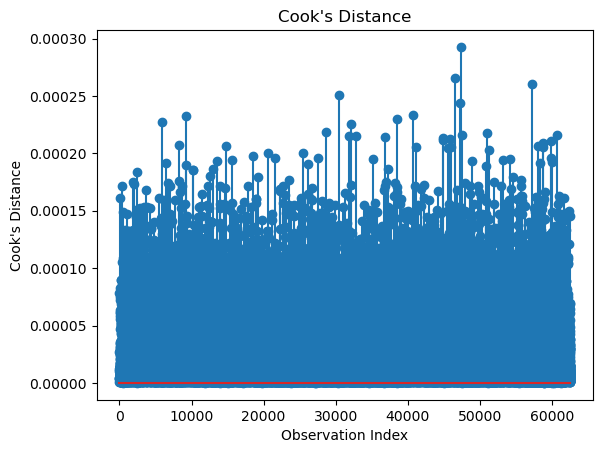

Indices of influential observations: []


In [42]:
# Cook's distance to check for outliers in final model
# Code adapted from Statology:
# Bobbit, Z. (2020). How to Calculate Cook’s Distance in Python
# Retrieved September 7 2025, from https://www.statology.org/cooks-distance-python/


# Suppress scientific notation
np.set_printoptions(suppress=True)

# Create instance of influence
influence = final_model.get_influence()

# Obtain Cook's distance for each observation
cooks = influence.cooks_distance

# Display Cook's distances
print(cooks)


# Visualize cook's distance

plt.stem(np.arange(len(cooks[0])), cooks[0], markerfmt="o")
plt.title("Cook's Distance")
plt.xlabel("Observation Index")
plt.ylabel("Cook's Distance")
plt.show()

# Identify influential observations
influential_points = np.where(cooks[0] > 0.02)
print("Indices of influential observations:", influential_points[0])

In [43]:
# Get coefficients and calculate odds ratios
coefficients = final_model.params
odds_ratios = np.exp(coefficients)

# Exclude intercept from analysis
odds_ratios = odds_ratios.drop('const', errors='ignore')

# Interpret each odds ratio
for predictor, or_value in odds_ratios.items():
    if or_value > 1:
        print(f"The odds ratio for {predictor} is {or_value:.2f}, meaning that as {predictor} increases by one unit, the odds of the 
        outcome increase by {(or_value - 1) * 100:.2f}%.")
    elif or_value < 1:
        print(f"The odds ratio for {predictor} is {or_value:.2f}, meaning that as {predictor} increases by one unit, the odds of the 
        outcome decrease by {(1 - or_value) * 100:.2f}%.")
    else:
        print(f"The odds ratio for {predictor} is {or_value:.2f}, meaning that {predictor} has no effect on the odds of the outcome.")


The odds ratio for bmi is 1.04, meaning that as bmi increases by one unit, the odds of the outcome increase by 4.27%.
The odds ratio for smoke is 0.84, meaning that as smoke increases by one unit, the odds of the outcome decrease by 15.89%.
The odds ratio for alco is 0.79, meaning that as alco increases by one unit, the odds of the outcome decrease by 21.04%.
The odds ratio for active is 0.82, meaning that as active increases by one unit, the odds of the outcome decrease by 17.60%.
The odds ratio for gender_male is 1.05, meaning that as gender_male increases by one unit, the odds of the outcome increase by 5.19%.
The odds ratio for cholesterol_above_normal is 1.54, meaning that as cholesterol_above_normal increases by one unit, the odds of the outcome increase by 53.90%.
The odds ratio for cholesterol_well_above_normal is 3.56, meaning that as cholesterol_well_above_normal increases by one unit, the odds of the outcome increase by 255.85%.
The odds ratio for glucose_well_above_normal i